# Coffee Shop Daily Revenue Forecasting
**Author:** Shehryar Hassan  
**Course:** Time Series Forecasting — Final Assignment  
**Dataset:** Coffee shop transaction-level data (aggregated to daily revenue)

In [2]:
### 1. Imports and Environment Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima          
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,    
    mean_squared_error,
    root_mean_squared_error
)
import warnings
warnings.filterwarnings('ignore')

# Global plot style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

c:\Users\Shehryar\anaconda3\envs\ts_EDA\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
### 2. Data Loading, Aggregation, and EDA
# 2.1 Load raw transaction data
df = pd.read_csv('https://raw.githubusercontent.com/Shehrhass/Time-Series-and-Demand-planning/main/index_1.csv')
df['datetime'] = pd.to_datetime(df['datetime'])

print('~~~ Raw Dataset Overview ~~~')
print(f'Shape: {df.shape}')
print('\nFirst 5 rows:')
print(df.head())
print('\nData types & non-null counts:')
print(df.info())
print('\nDescriptive statistics (transaction-level):')
print(df.describe())
print('\nMissing values per column:')
print(df.isnull().sum())

~~~ Raw Dataset Overview ~~~
Shape: (3636, 6)

First 5 rows:
         date                datetime cash_type                 card  money  \
0  2024-03-01 2024-03-01 10:15:50.520      card  ANON-0000-0000-0001   38.7   
1  2024-03-01 2024-03-01 12:19:22.539      card  ANON-0000-0000-0002   38.7   
2  2024-03-01 2024-03-01 12:20:18.089      card  ANON-0000-0000-0002   38.7   
3  2024-03-01 2024-03-01 13:46:33.006      card  ANON-0000-0000-0003   28.9   
4  2024-03-01 2024-03-01 13:48:14.626      card  ANON-0000-0000-0004   38.7   

     coffee_name  
0          Latte  
1  Hot Chocolate  
2  Hot Chocolate  
3      Americano  
4          Latte  

Data types & non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         3636 non-null   object        
 1   datetime     3636 non-null   datetime64[ns]
 2   cash_type   

In [ ]:
### 2.2 Aggregate to daily revenue time series

daily_revenue = (
    df.groupby(df['datetime'].dt.date)['money']
    .sum()
    .reset_index()
)
daily_revenue.columns = ['date', 'revenue']
daily_revenue['date'] = pd.to_datetime(daily_revenue['date'])
daily_revenue.set_index('date', inplace=True)

# Reindex to a full calendar range and treated missing values as closed days (no transactions recorded).
idx = pd.date_range(start=daily_revenue.index.min(), end=daily_revenue.index.max())
daily_revenue = daily_revenue.reindex(idx, fill_value=0)
daily_revenue.index.name = 'date'

print(f'Daily revenue series: {len(daily_revenue)} days')
print(f'Date range: {daily_revenue.index.min().date()} --> {daily_revenue.index.max().date()}')
print(f'Zero-revenue days (closed): {(daily_revenue["revenue"] == 0).sum()}')

Daily revenue series: 388 days
Date range: 2024-03-01 --> 2025-03-23
Zero-revenue days (closed): 7


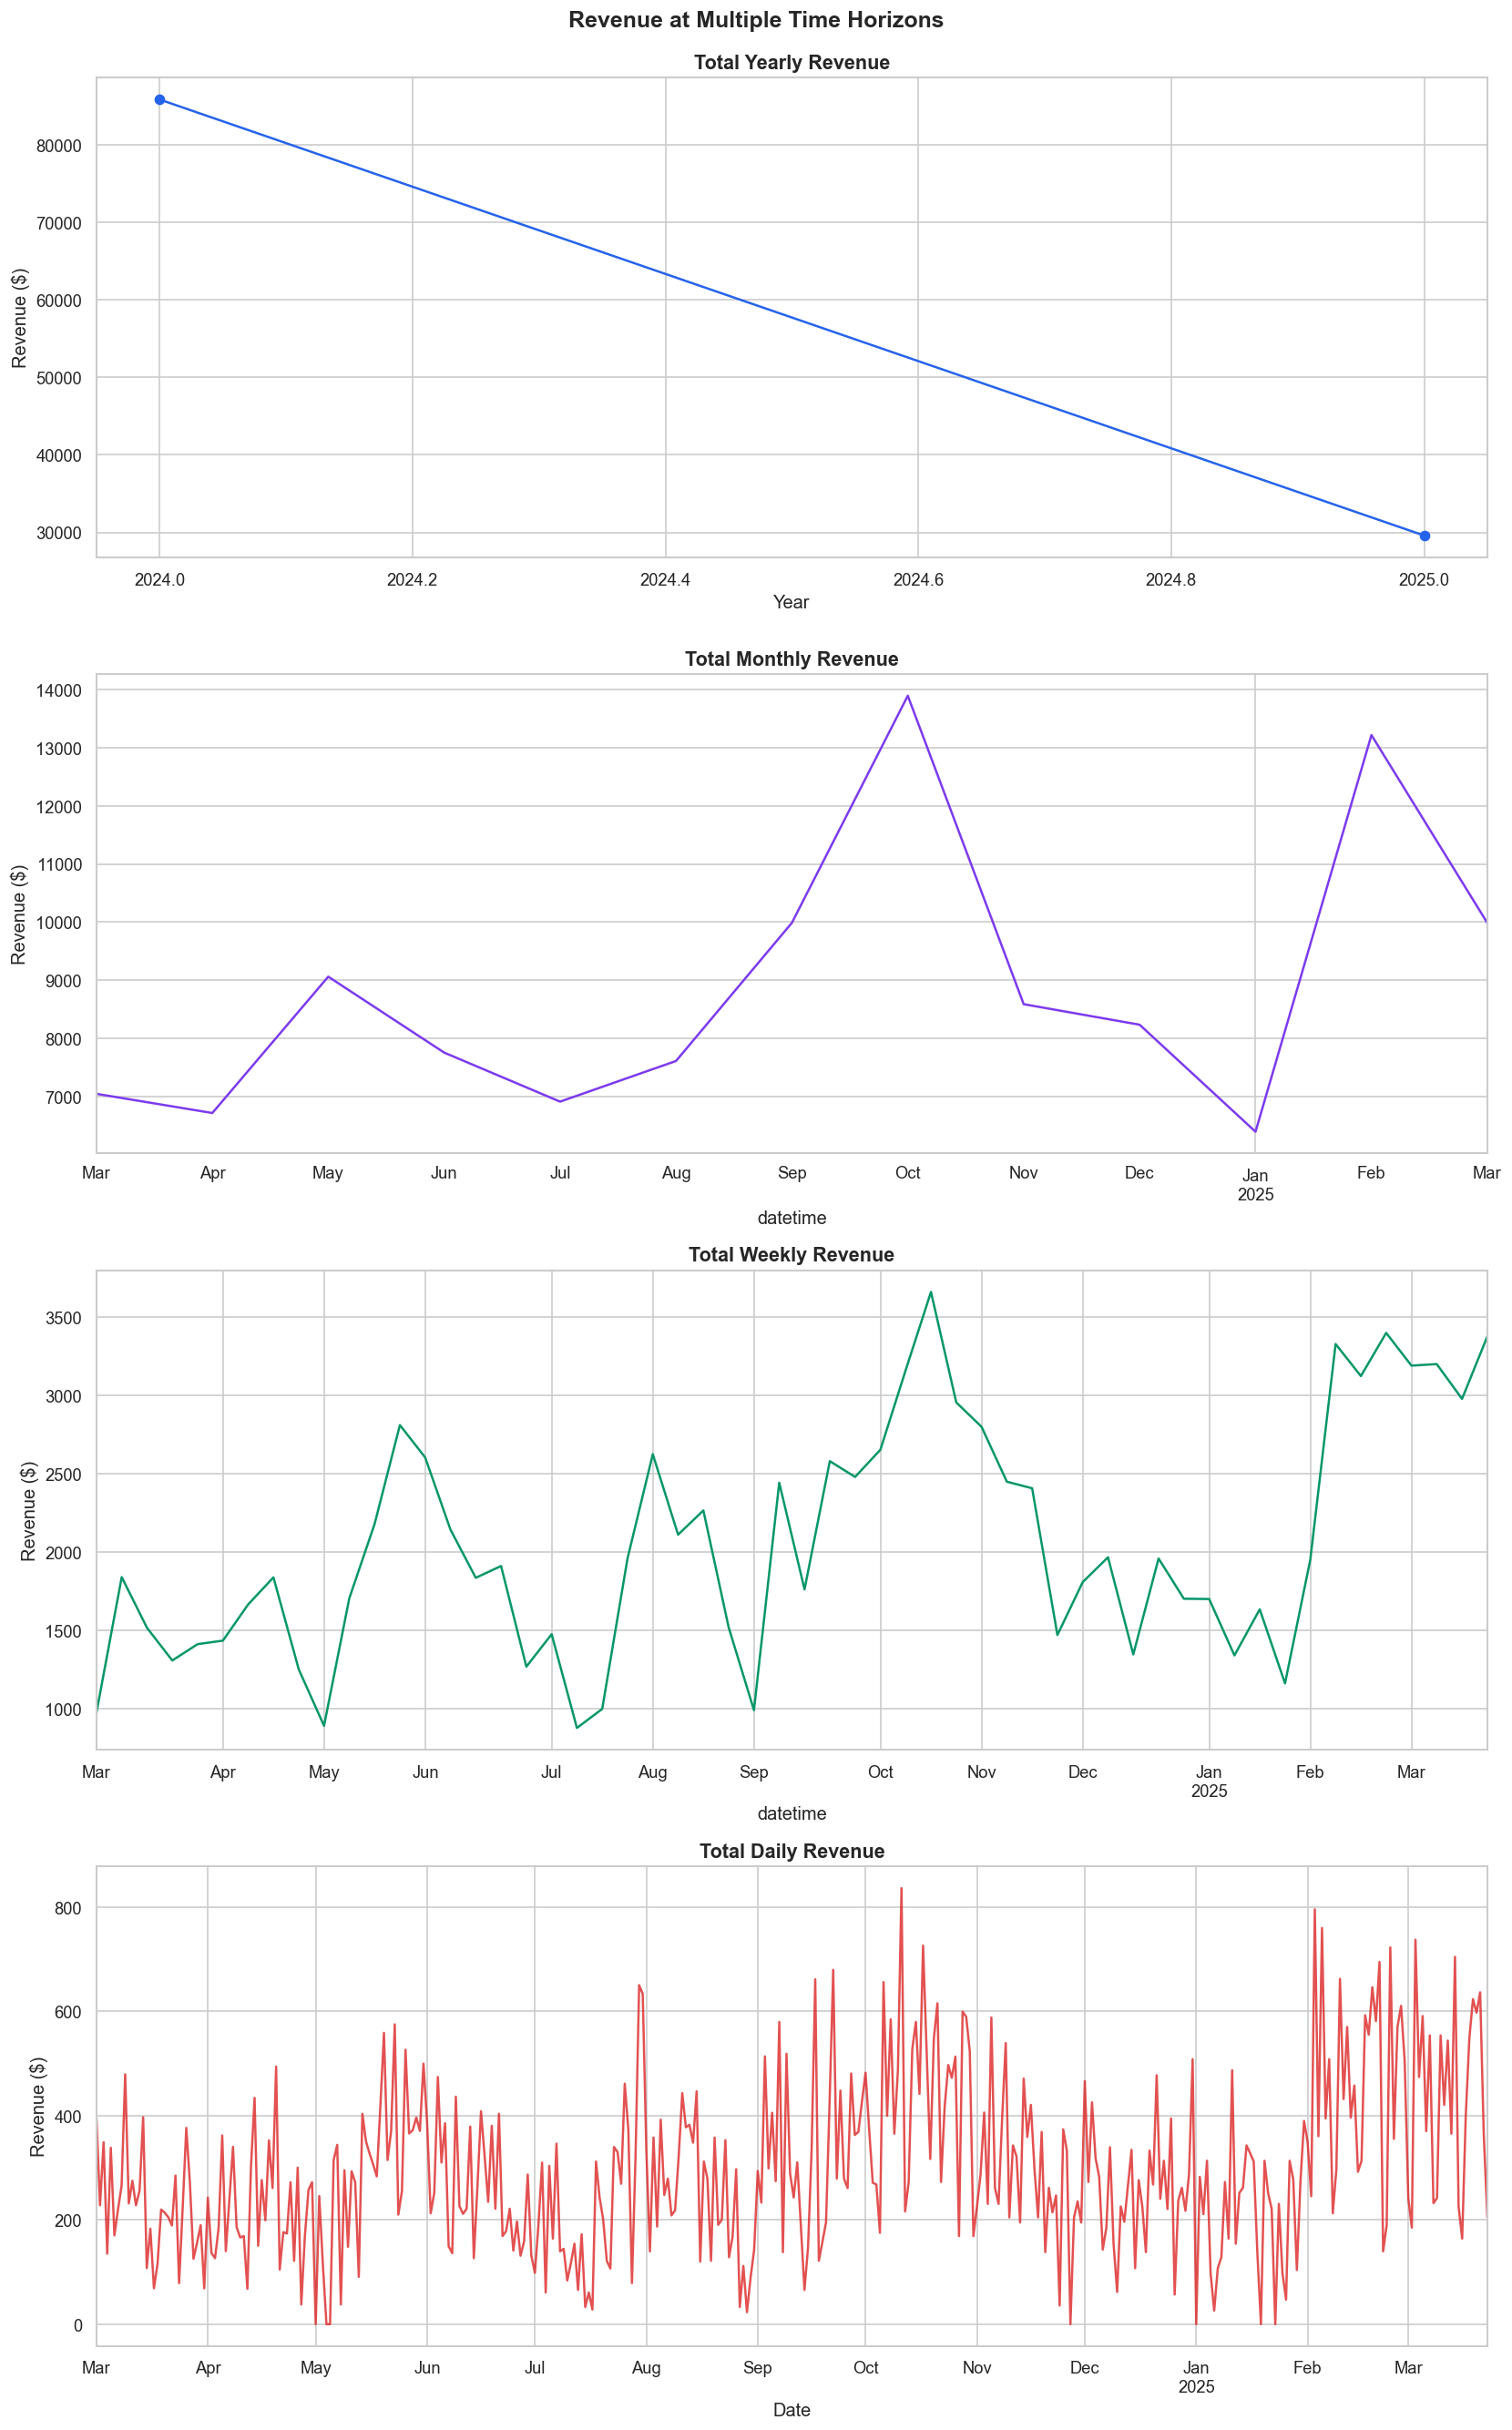

In [5]:
### 2.3 EDA — Multi-horizon visualisation (daily, weekly, monthly, yearly)

df['Year']       = df['datetime'].dt.year
df['Month']      = df['datetime'].dt.month
df['Month_Name'] = df['datetime'].dt.month_name()
df['Week']       = df['datetime'].dt.isocalendar().week
df['Day']        = df['datetime'].dt.isocalendar().day

yearly_sales  = df.groupby('Year')['money'].sum()
monthly_sales = df.set_index('datetime').resample('ME')['money'].sum()
weekly_sales  = df.set_index('datetime').resample('W')['money'].sum()

fig, axes = plt.subplots(4, 1, figsize=(14, 22))

yearly_sales.plot(ax=axes[0], marker='o', color='#2563eb')
axes[0].set_title('Total Yearly Revenue', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Revenue ($)')

monthly_sales.plot(ax=axes[1], color='#7c3aed')
axes[1].set_title('Total Monthly Revenue', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Revenue ($)')

weekly_sales.plot(ax=axes[2], color='#059669')
axes[2].set_title('Total Weekly Revenue', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Revenue ($)')

daily_revenue['revenue'].plot(ax=axes[3], color='#dc2626', alpha=0.8)
axes[3].set_title('Total Daily Revenue', fontsize=13, fontweight='bold')
axes[3].set_ylabel('Revenue ($)')
axes[3].set_xlabel('Date')

plt.tight_layout()
plt.suptitle('Revenue at Multiple Time Horizons', fontsize=15, fontweight='bold', y=1.01)
plt.show()

IQR fences: lower=$-117.38, upper=$687.77
Outlier days detected: 8
            revenue
date               
2024-10-11   836.66
2024-10-17   726.46
2025-02-03   796.00
2025-02-05   760.24
2025-02-21   695.08
2025-02-24   723.02
2025-03-03   737.72
2025-03-14   704.88


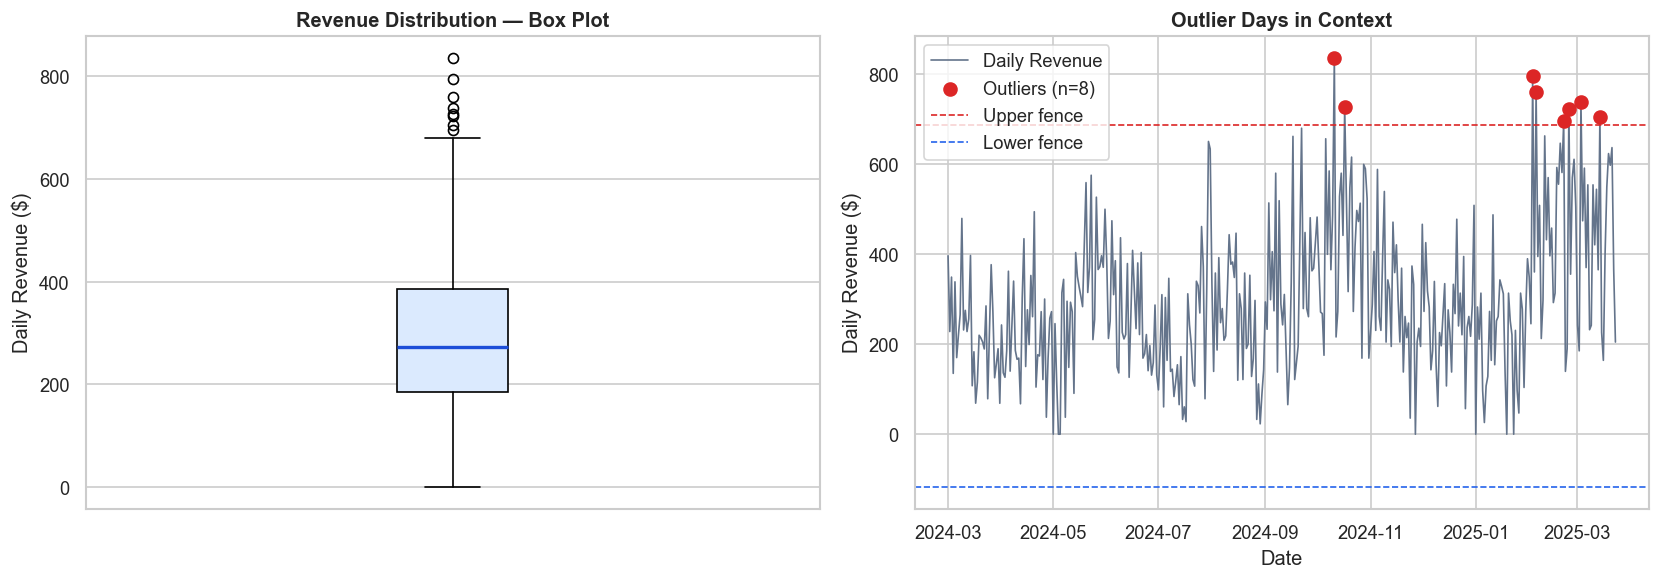

In [ ]:
### 2.4 EDA

Q1  = daily_revenue['revenue'].quantile(0.25)
Q3  = daily_revenue['revenue'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers = daily_revenue[
    (daily_revenue['revenue'] < lower_fence) |
    (daily_revenue['revenue'] > upper_fence)
]
print(f'IQR fences: lower=${lower_fence:.2f}, upper=${upper_fence:.2f}')
print(f'Outlier days detected: {len(outliers)}')
print(outliers)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
axes[0].boxplot(daily_revenue['revenue'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#dbeafe'), medianprops=dict(color='#1d4ed8', linewidth=2))
axes[0].set_title('Revenue Distribution — Box Plot', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Daily Revenue ($)')
axes[0].set_xticks([])

# Time series with outliers highlighted
axes[1].plot(daily_revenue.index, daily_revenue['revenue'], color='#64748b', linewidth=1, label='Daily Revenue')
axes[1].scatter(outliers.index, outliers['revenue'], color='#dc2626', zorder=5, s=60, label=f'Outliers (n={len(outliers)})')
axes[1].axhline(upper_fence, color='#dc2626', linestyle='--', linewidth=1, label='Upper fence')
axes[1].axhline(lower_fence, color='#2563eb', linestyle='--', linewidth=1, label='Lower fence')
axes[1].set_title('Outlier Days in Context', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Daily Revenue ($)')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.show()

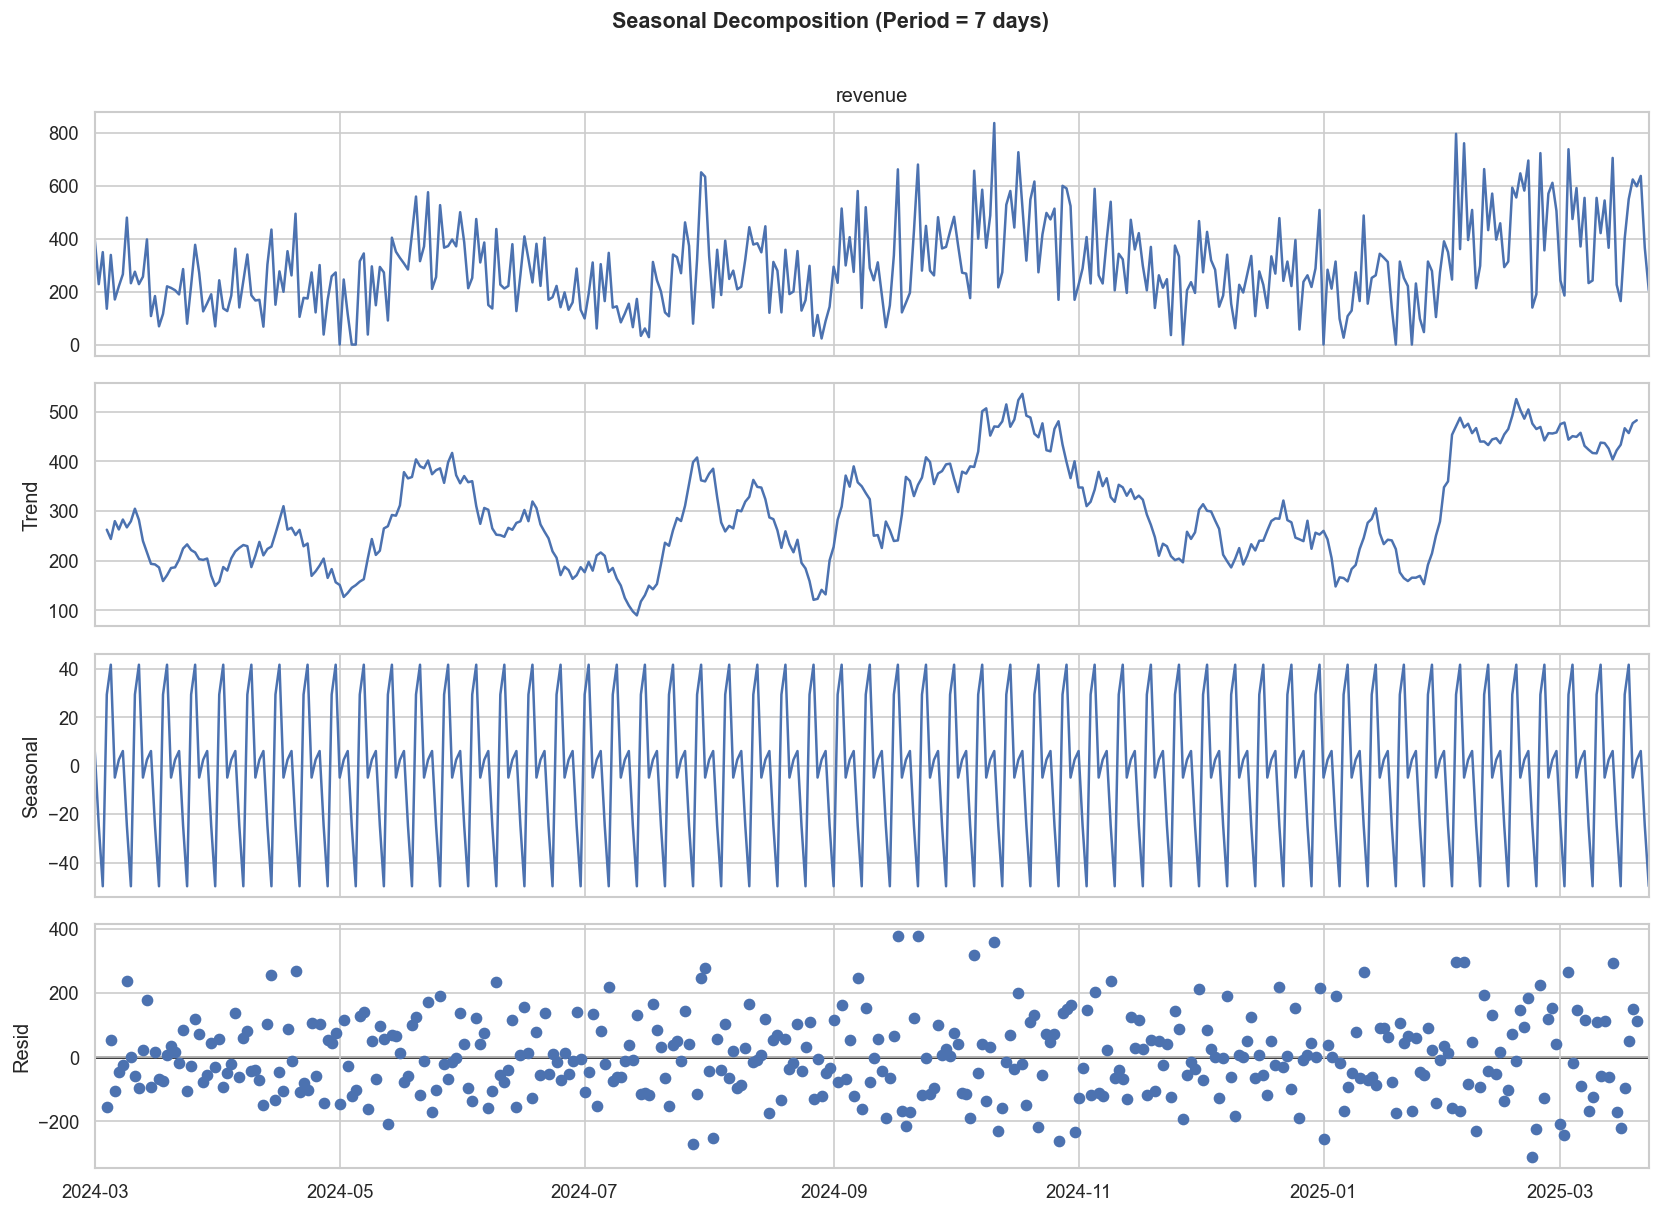

In [ ]:
### 3. Time Series Analysis
# 3.1 Seasonal Decomposition
decomposition = seasonal_decompose(daily_revenue['revenue'], model='additive', period=7)
fig = decomposition.plot()
fig.set_size_inches(14, 10)
fig.suptitle('Seasonal Decomposition (Period = 7 days)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
### 3.2 ADF vs KPSS

adf_result  = adfuller(daily_revenue['revenue'])
kpss_result = kpss(daily_revenue['revenue'], regression='c')

adf_p  = adf_result[1]
kpss_p = kpss_result[1]

print('~~~ Stationarity Check - Original Series ~~~')
print(f'ADF  p-value: {adf_p:.4f}  --> {"Stationary" if adf_p < 0.05 else "Non-stationary"} (reject unit root if p < 0.05)')
print(f'KPSS p-value: {kpss_p:.4f}  --> {"Stationary" if kpss_p > 0.05 else "Non-stationary"} (reject stationarity if p < 0.05)')

# Interpret the conflict
if adf_p < 0.05 and kpss_p < 0.05:
    print()
    print(' CONFLICT: ADF and KPSS disagree.')
    print('   Interpretation: The series is likely TREND-STATIONARY.')
    print('   ADF rejects a unit root (no random walk drift) but KPSS detects a deterministic trend.')
    print('   Action: Apply first differencing to confirm and de-trend before using ARIMA.')

# Verify by re-testing on first-differences
diff_revenue = daily_revenue['revenue'].diff().dropna()
adf_diff_p  = adfuller(diff_revenue)[1]
kpss_diff_p = kpss(diff_revenue, regression='c')[1]

print()
print('~~~ Stationarity Check - First-Differenced Series ~~~')
print(f'ADF  p-value: {adf_diff_p:.4f}  --> {"It is now Stationary" if adf_diff_p < 0.05 else "Non-stationary"}')
print(f'KPSS p-value: {kpss_diff_p:.4f}  --> {"It is now Stationary" if kpss_diff_p > 0.05 else "Non-stationary"}')
print()
if adf_diff_p < 0.05 and kpss_diff_p > 0.05:
    print('Both tests show that the differenced series is stationary. d=1 is appropriate for ARIMA.')
else:
    print('Consider d=2 or seasonal differencing.')

~~~ Stationarity Check - Original Series ~~~
ADF  p-value: 0.0305  --> Stationary (reject unit root if p < 0.05)
KPSS p-value: 0.0100  --> Non-stationary (reject stationarity if p < 0.05)

 CONFLICT: ADF and KPSS disagree.
   Interpretation: The series is likely TREND-STATIONARY.
   ADF rejects a unit root (no random walk drift) but KPSS detects a deterministic trend.
   Action: Apply first differencing to confirm and de-trend before using ARIMA.

~~~ Stationarity Check - First-Differenced Series ~~~
ADF  p-value: 0.0000  --> It is now Stationary
KPSS p-value: 0.1000  --> It is now Stationary

Both tests show that the differenced series is stationary. d=1 is appropriate for ARIMA.


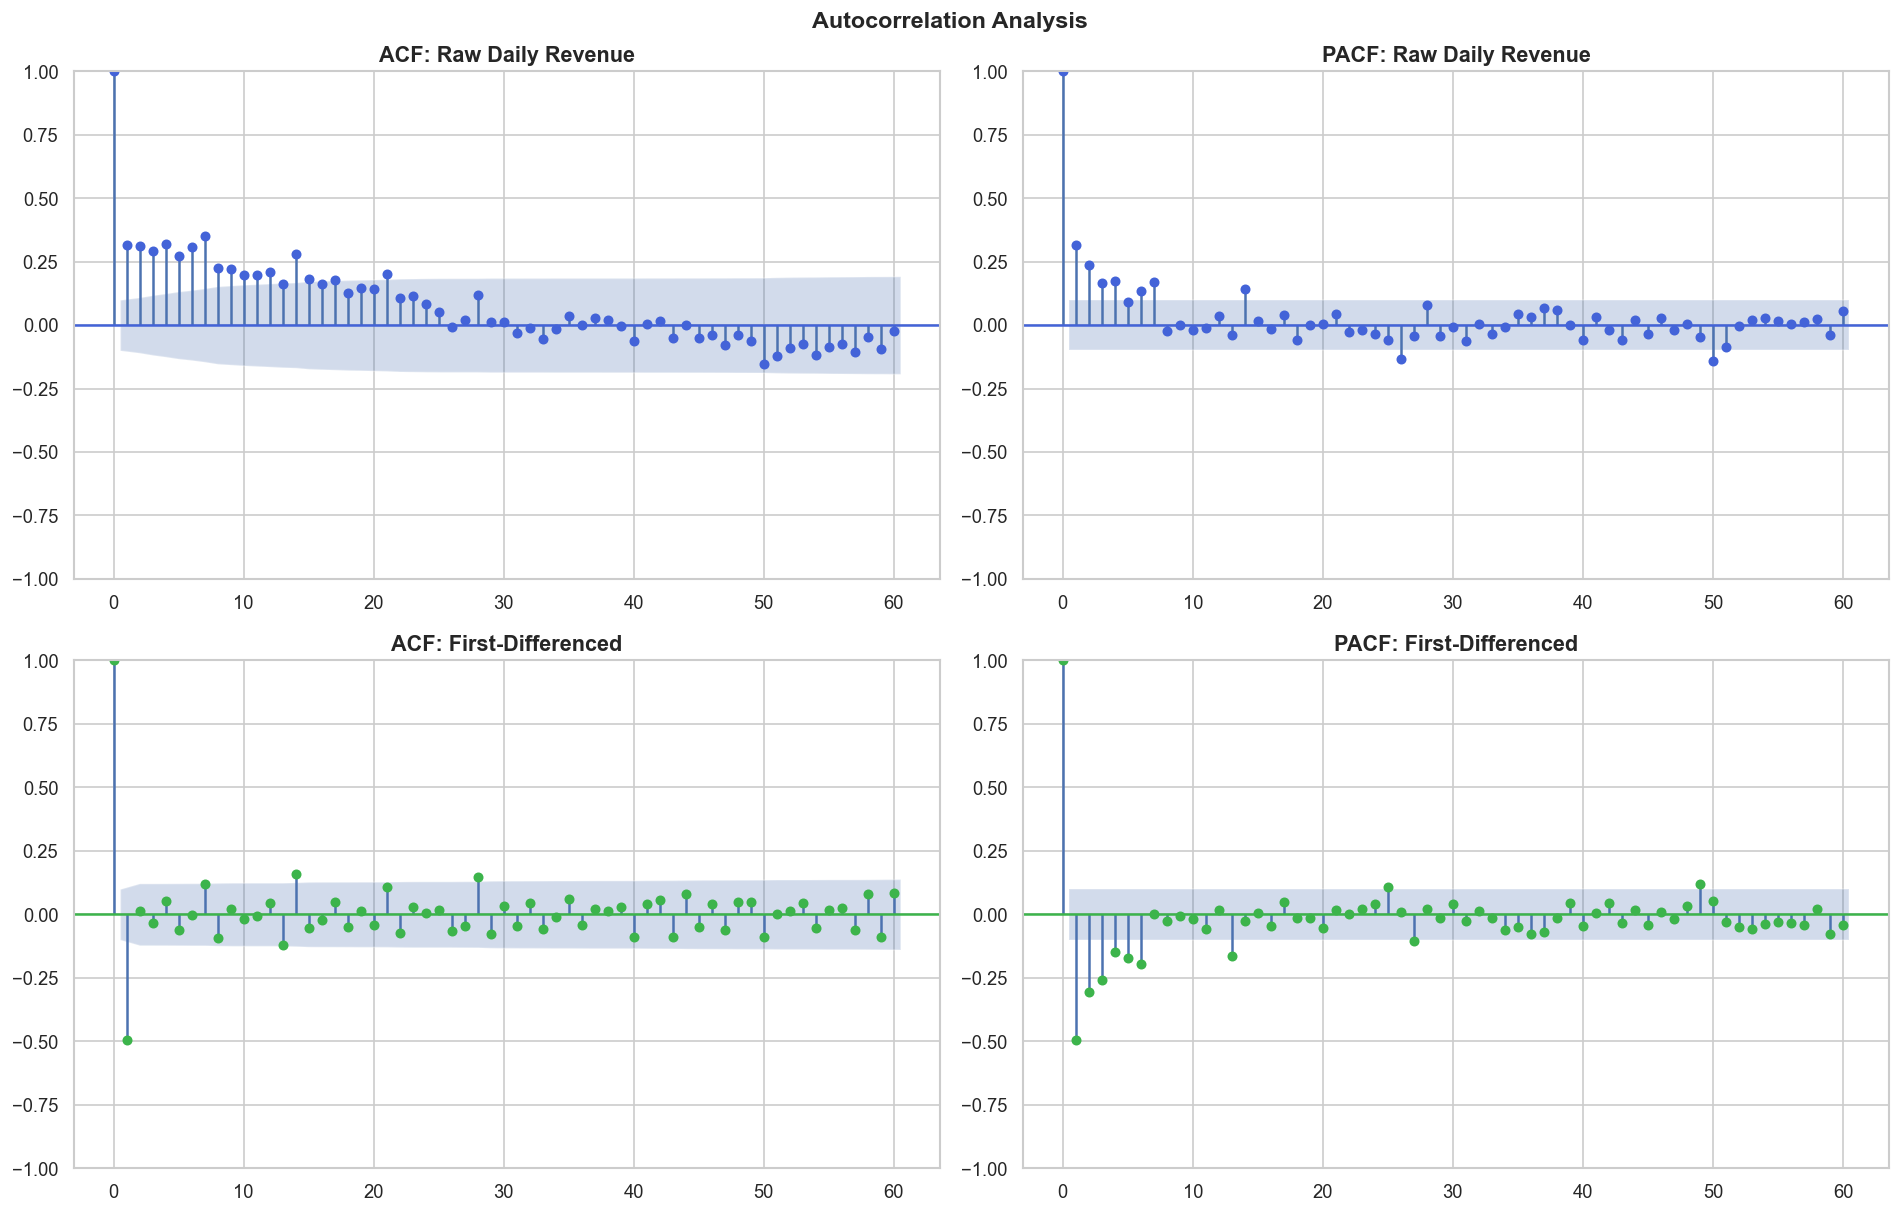

Interpretation:
  ACF raw: Slow decay confirms autocorrelation, spikes at lag 7/14 confirm weekly seasonality.
  PACF raw: Significant spike at lag 1 and lag 7 --> AR(1) and AR(7).


In [9]:
### 3.3 ACF and PACF Plots (raw + differenced)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

plot_acf(daily_revenue['revenue'],  lags=60, ax=axes[0, 0], color='#4363d8')
axes[0, 0].set_title('ACF: Raw Daily Revenue',       fontsize=13, fontweight='bold')

plot_pacf(daily_revenue['revenue'], lags=60, ax=axes[0, 1], color='#4363d8', method='ywm')
axes[0, 1].set_title('PACF: Raw Daily Revenue',      fontsize=13, fontweight='bold')

plot_acf(diff_revenue,  lags=60, ax=axes[1, 0], color='#3cb44b')
axes[1, 0].set_title('ACF: First-Differenced',       fontsize=13, fontweight='bold')

plot_pacf(diff_revenue, lags=60, ax=axes[1, 1], color='#3cb44b', method='ywm')
axes[1, 1].set_title('PACF: First-Differenced',      fontsize=13, fontweight='bold')

plt.tight_layout()
plt.suptitle('Autocorrelation Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.show()

print('Interpretation:')
print('  ACF raw: Slow decay confirms autocorrelation, spikes at lag 7/14 confirm weekly seasonality.')
print('  PACF raw: Significant spike at lag 1 and lag 7 --> AR(1) and AR(7).')

In [ ]:
### 4. Feature Engineering

def create_features(data):
    """
    Adding calendar and lag-based features to the daily revenue df.
    All features are derived from info available before the forecast day
    (preventing data leakage).
    """
    df_feat = data.copy()
   
    df_feat['dayofweek'] = df_feat.index.dayofweek 
    df_feat['month'] = df_feat.index.month
    df_feat['is_weekend'] = np.where(df_feat.index.dayofweek >= 5, 1, 0)
    # Lag features (exploit weekly seasonality)
    df_feat['lag_1'] = df_feat['revenue'].shift(1) 
    df_feat['lag_7'] = df_feat['revenue'].shift(7)  
    df_feat['lag_14'] = df_feat['revenue'].shift(14)  
    # Rolling statistics
    df_feat['rolling_mean_7'] = df_feat['revenue'].rolling(window=7).mean()
    df_feat['rolling_std_7']  = df_feat['revenue'].rolling(window=7).std()   
    return df_feat.dropna()

model_df = create_features(daily_revenue)

print(f'Feature matrix shape: {model_df.shape}')
print(f'Features used: {[c for c in model_df.columns if c != "revenue"]}')

Feature matrix shape: (374, 9)
Features used: ['dayofweek', 'month', 'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7']


Training period : 2024-03-15 → 2025-01-07  (299 days)
Test period     : 2025-01-08  → 2025-03-23   (75 days)


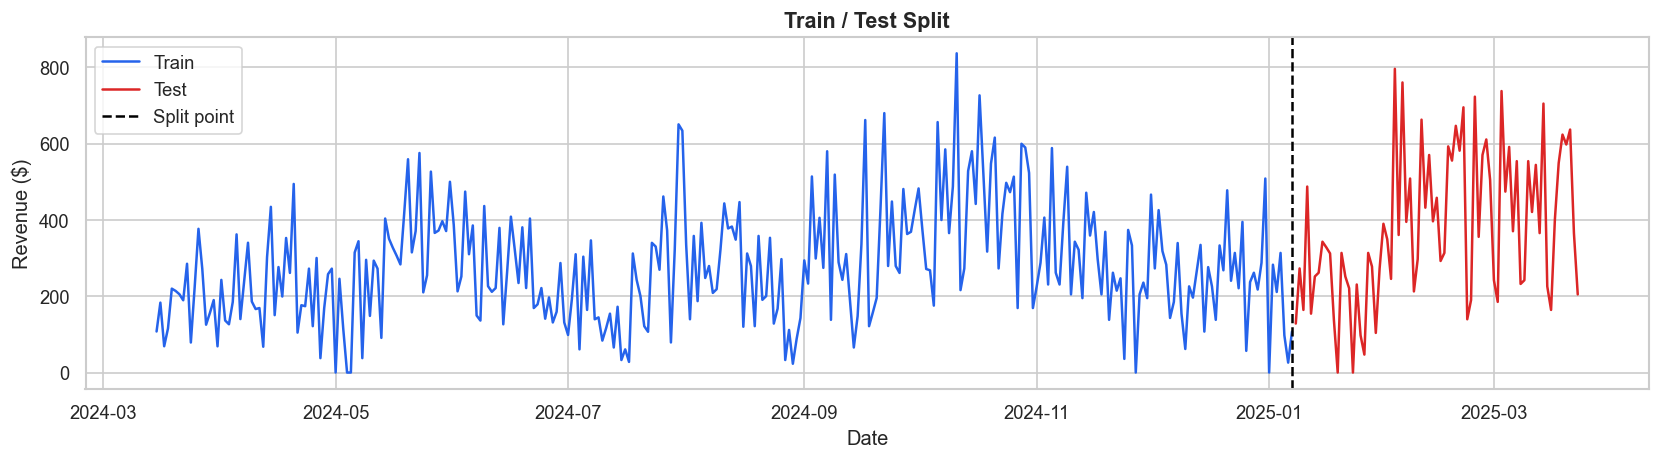

In [11]:
### 5. Train:Test Split (80 : 20)

train_size = int(len(model_df) * 0.8)
train = model_df.iloc[:train_size]
test  = model_df.iloc[train_size:]

# Feature matrices for SKlearn/XGBoost models
feature_cols = [c for c in model_df.columns if c != 'revenue']
X_train = train[feature_cols]
X_test  = test[feature_cols]
y_train = train['revenue']
y_test  = test['revenue']

print(f'Training period : {train.index.min().date()} → {train.index.max().date()}  ({len(train)} days)')
print(f'Test period     : {test.index.min().date()}  → {test.index.max().date()}   ({len(test)} days)')

# Visualisation of split
plt.figure(figsize=(14, 4))
plt.plot(train.index, y_train, label='Train', color='#2563eb')
plt.plot(test.index,  y_test,  label='Test',  color='#dc2626')
plt.axvline(x=train.index[-1], color='black', linestyle='--', linewidth=1.5, label='Split point')
plt.title('Train / Test Split', fontsize=13, fontweight='bold')
plt.ylabel('Revenue ($)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
### 6. Model Training
# 6.1  XGBoost
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
print('~~~XGBoost trained~~~')

# 6.2  Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
print('~~~Linear Regression trained~~~')

# 6.3  ARIMA 
print('\nRunning auto_arima to select optimal ARIMA order...')
auto_model = auto_arima(
    train['revenue'],
    seasonal=False,        
    stepwise=True,        
    information_criterion='aic',
    max_p=7, max_q=3,
    suppress_warnings=True
)
print(f'Best ARIMA order: {auto_model.order}  (AIC={auto_model.aic():.1f})')
print(auto_model.summary())
# ARIMA with the auto-selection
arima_model = ARIMA(train['revenue'], order=auto_model.order)
arima_fit = arima_model.fit()
arima_result = arima_fit.get_forecast(steps=len(test))
arima_preds = arima_result.predicted_mean.values
arima_ci = arima_result.conf_int(alpha=0.05) 
print('\n ~~~ARIMA trained~~~')

# 6.4  Prophet + Engineered Regressors
prophet_train = train.copy()
prophet_train['ds'] = prophet_train.index
prophet_train['y']  = prophet_train['revenue']
prophet_train = prophet_train.reset_index(drop=True)

prophet_test = test.copy()
prophet_test['ds'] = prophet_test.index
prophet_test['y']  = prophet_test['revenue']
prophet_test = prophet_test.reset_index(drop=True)

m = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=False)
for reg in ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'is_weekend']:
    m.add_regressor(reg)
m.fit(prophet_train)

future         = prophet_test.drop(columns=['y'])
forecast       = m.predict(future)
prophet_preds  = forecast['yhat'].values
prophet_lower  = forecast['yhat_lower'].values    
prophet_upper  = forecast['yhat_upper'].values   
print('~~~Prophet trained~~~')

~~~XGBoost trained~~~
~~~Linear Regression trained~~~

Running auto_arima to select optimal ARIMA order...
Best ARIMA order: (0, 1, 1)  (AIC=3776.8)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  299
Model:               SARIMAX(0, 1, 1)   Log Likelihood               -1886.407
Date:                Thu, 02 Apr 2026   AIC                           3776.814
Time:                        23:00:58   BIC                           3784.208
Sample:                    03-15-2024   HQIC                          3779.774
                         - 01-07-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8401      0.030    -28.444      0.000      -

23:01:01 - cmdstanpy - INFO - Chain [1] start processing
23:01:01 - cmdstanpy - INFO - Chain [1] done processing


~~~Prophet trained~~~


In [ ]:
### 7. Inverse-RMSE Weighted Ensemble
rmse = {
    'xgb'     : root_mean_squared_error(y_test, xgb_preds),
    'lr'      : root_mean_squared_error(y_test, lr_preds),
    'arima'   : root_mean_squared_error(y_test, arima_preds),
    'prophet' : root_mean_squared_error(y_test, prophet_preds),
}

inv_rmse = {k: 1.0 / v for k, v in rmse.items()}
total    = sum(inv_rmse.values())
weights  = {k: v / total for k, v in inv_rmse.items()}

print('Ensemble weights (inverse-RMSE):')
for model_name, w in weights.items():
    print(f'  {model_name:<10}: {w:.4f}  (weight)')

ensemble_preds = (
    xgb_preds     * weights['xgb']  +
    lr_preds      * weights['lr']   +
    arima_preds   * weights['arima'] +
    prophet_preds * weights['prophet']
)

Ensemble weights (inverse-RMSE):
  xgb       : 0.2700  (weight)
  lr        : 0.2822  (weight)
  arima     : 0.1752  (weight)
  prophet   : 0.2726  (weight)


In [14]:
### 8. Model Evaluation

def mda(actual, predicted):
    """Mean Directional Accuracy: % of days where direction of change is correctly forecast."""
    actual_diff = np.sign(np.diff(actual))
    pred_diff   = np.sign(np.diff(predicted))
    return np.mean(actual_diff == pred_diff) * 100

actual = y_test.values

models = {
    'XGBoost'          : xgb_preds,
    'Linear Regression': lr_preds,
    'ARIMA'            : arima_preds,
    'Prophet'          : prophet_preds,
    'Wtd. Ensemble'    : ensemble_preds,
}

results = {}
print(f"{'Model':<22} {'MAE':>8} {'RMSE':>8} {'MDA':>8}")
print('-' * 58)
for name, preds in models.items():
    mae  = mean_absolute_error(actual, preds)
    rmse = root_mean_squared_error(actual, preds)
    mda_ = mda(actual, preds)
    results[name] = dict(MAE=mae, RMSE=rmse, MDA=mda_)
    print(f'{name:<22} ${mae:>6.2f}  ${rmse:>6.2f}  {mda_:>6.2f}%')

# Summary
results_df = pd.DataFrame(results).T.round(2)
print()
print('Best model by MAE  :', results_df['MAE'].idxmin())
print('Best model by RMSE :', results_df['RMSE'].idxmin())
print('Best model by MDA  :', results_df['MDA'].idxmax())

Model                       MAE     RMSE      MDA
----------------------------------------------------------
XGBoost                $135.93  $179.73   62.16%
Linear Regression      $138.02  $171.93   58.11%
ARIMA                  $220.65  $276.94    0.00%
Prophet                $141.88  $178.00   47.30%
Wtd. Ensemble          $140.98  $173.41   56.76%

Best model by MAE  : XGBoost
Best model by RMSE : Linear Regression
Best model by MDA  : XGBoost


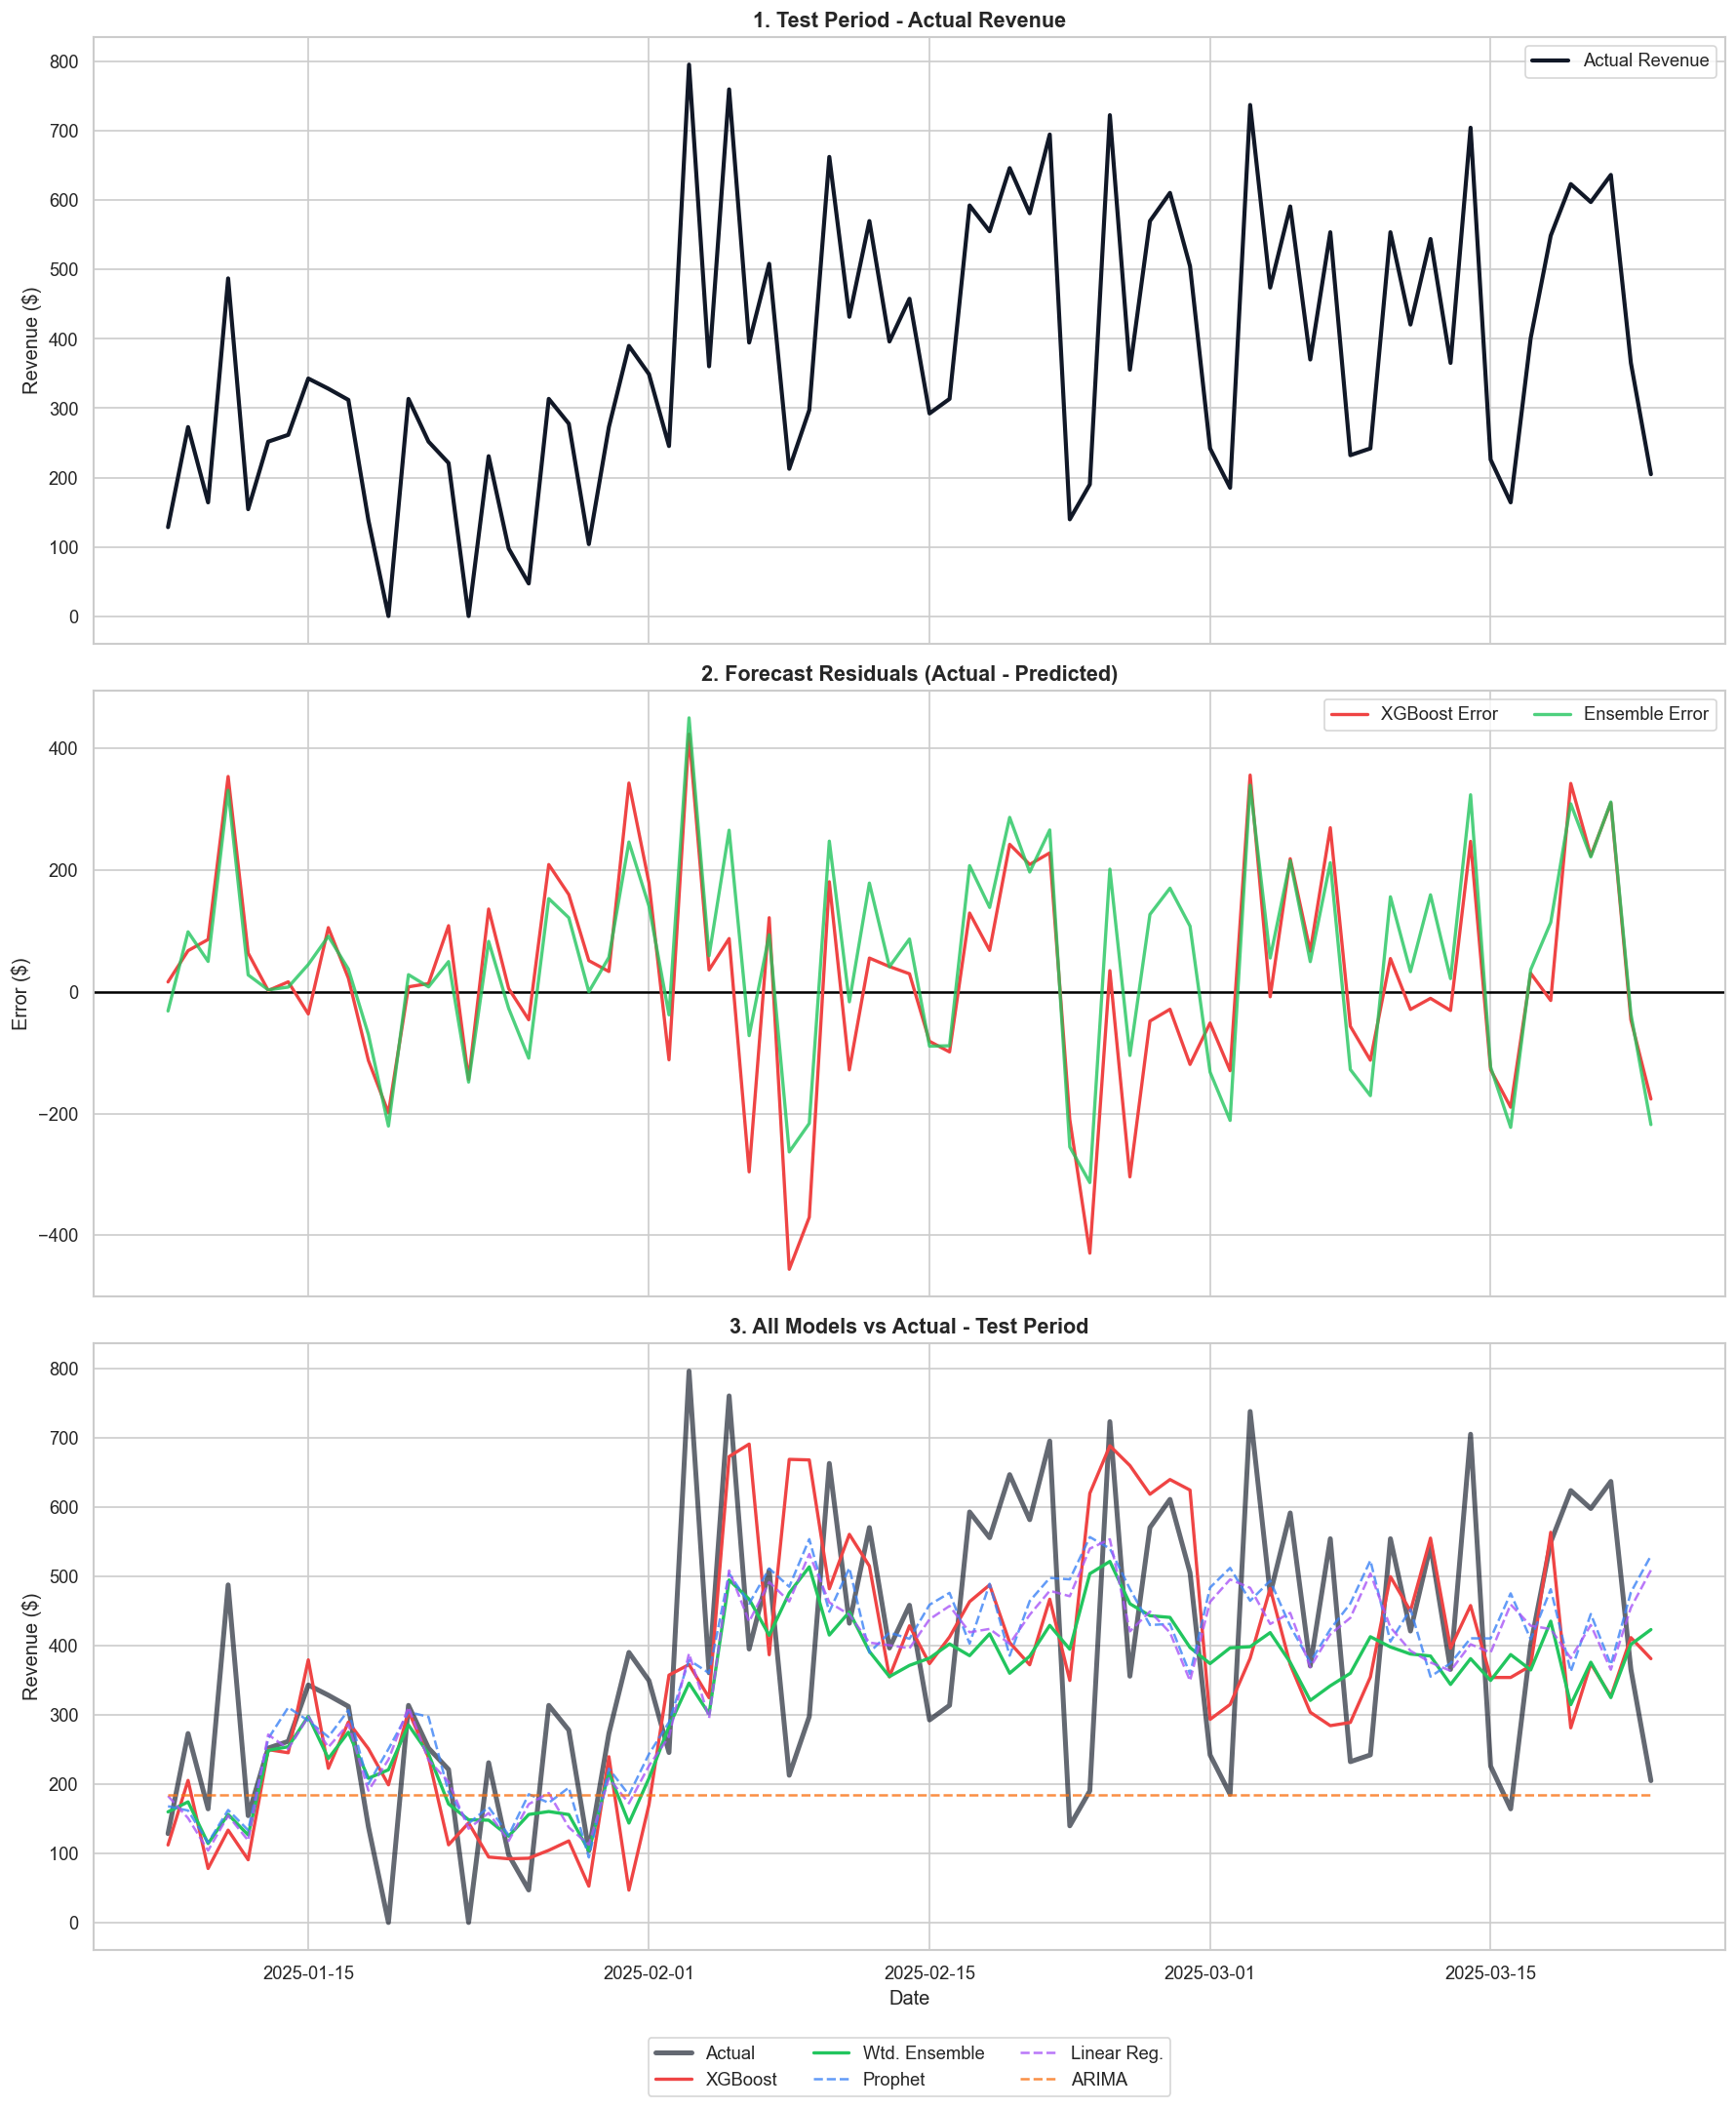

In [21]:
### 9. Main Visualisation

color_actual   = '#111827'
color_xgb      = '#ef4444'
color_ensemble = '#22c55e'
color_prophet  = '#3b82f6'
color_lr       = '#a855f7'
color_arima    = '#f97316'

fig, axes = plt.subplots(3, 1, figsize=(15, 18), sharex=True)

# Panel 1: Actual
axes[0].plot(test.index, actual, color=color_actual, linewidth=2.5, label='Actual Revenue')
axes[0].set_title('1. Test Period - Actual Revenue', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Revenue ($)')
axes[0].legend()

# Panel 2: Residuals for the two 'best' models
res_xgb      = actual - xgb_preds
res_ensemble = actual - ensemble_preds
axes[1].axhline(0, color='black', linewidth=1.5)
axes[1].plot(test.index, res_xgb,      label='XGBoost Error',    color=color_xgb,      linewidth=2)
axes[1].plot(test.index, res_ensemble, label='Ensemble Error',   color=color_ensemble, linewidth=2, alpha=0.8)
axes[1].set_title('2. Forecast Residuals (Actual - Predicted)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Error ($)')
axes[1].legend(ncol=2)

# Panel 3: All models vs actual
axes[2].plot(test.index, actual, label='Actual', color=color_actual, alpha=0.65, linewidth=3)
axes[2].plot(test.index, xgb_preds, label='XGBoost', color=color_xgb, linewidth=2)
axes[2].plot(test.index, ensemble_preds, label='Wtd. Ensemble', color=color_ensemble, linewidth=2)
axes[2].plot(test.index, prophet_preds, label='Prophet', color=color_prophet, linestyle='--', alpha=0.8, linewidth=1.5)
axes[2].plot(test.index, lr_preds, label='Linear Reg.', color=color_lr, linestyle='--', alpha=0.8, linewidth=1.5)
axes[2].plot(test.index, arima_preds, label='ARIMA', color=color_arima, linestyle='--', alpha=0.8, linewidth=1.5)
axes[2].set_title('3. All Models vs Actual - Test Period', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Revenue ($)')
axes[2].set_xlabel('Date')
axes[2].legend(loc='upper center', bbox_to_anchor=(0.5, -0.13), ncol=3, fontsize=11)

plt.tight_layout()
plt.subplots_adjust(bottom=0.07)
plt.show()

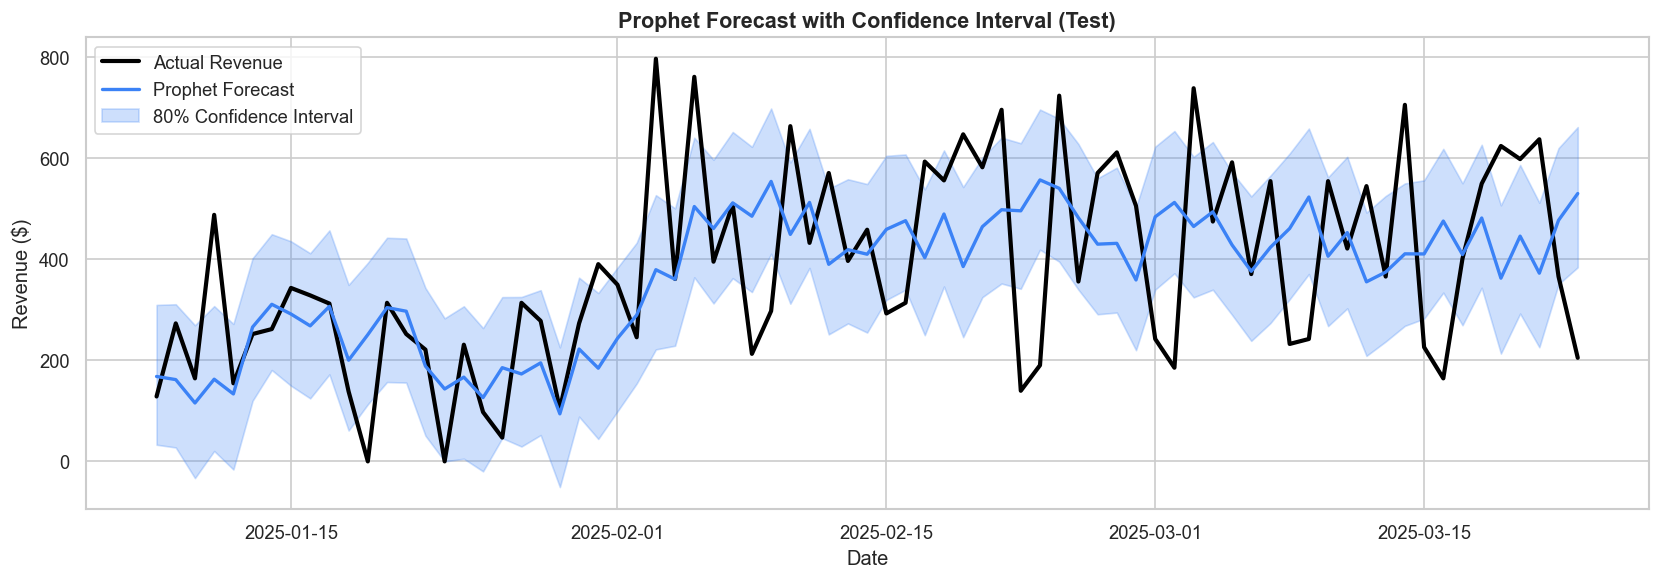

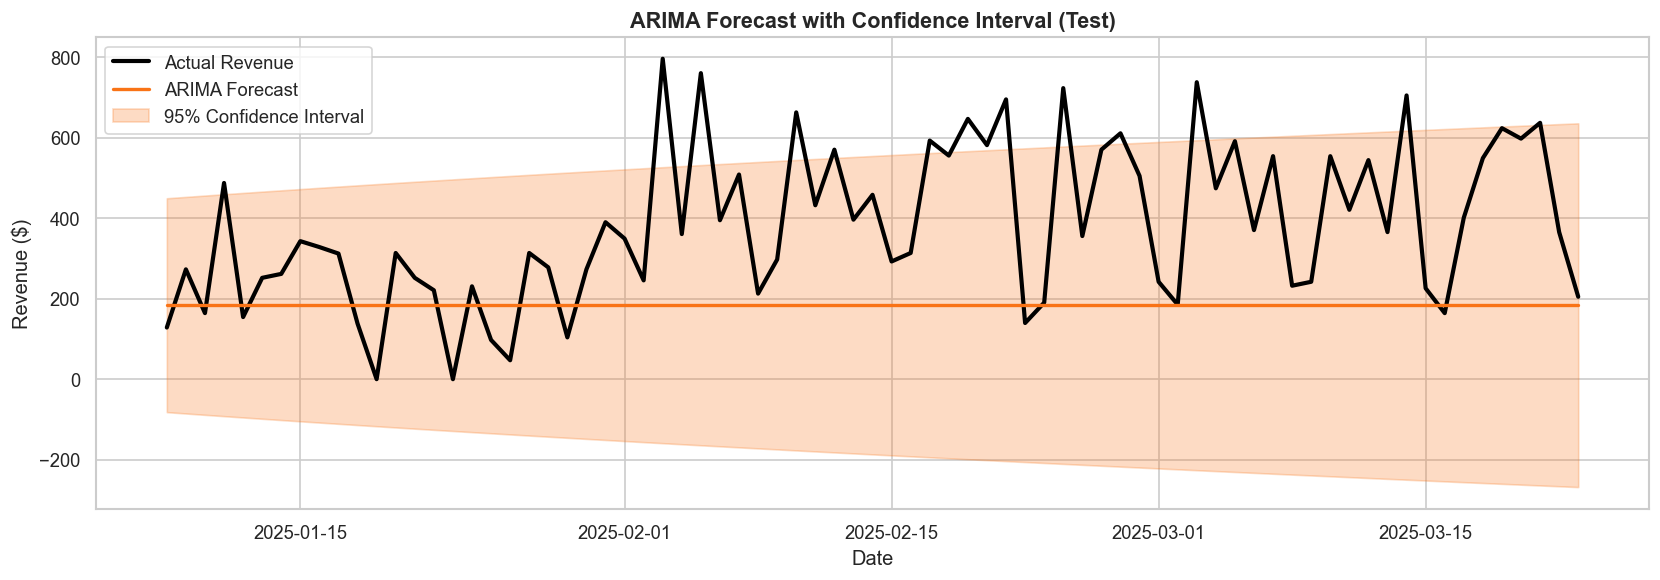

In [16]:
### 10. Confidence Intervals on Prophet and ARIMA forecasts
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index, actual,        color='black',   linewidth=2.5, label='Actual Revenue')
ax.plot(test.index, prophet_preds, color='#3b82f6', linewidth=2,   label='Prophet Forecast')
ax.fill_between(
    test.index,
    prophet_lower, prophet_upper,
    alpha=0.25, color='#3b82f6', label='80% Confidence Interval'
)
ax.set_title('Prophet Forecast with Confidence Interval (Test)', fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue ($)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index, actual,       color='black',   linewidth=2.5, label='Actual Revenue')
ax.plot(test.index, arima_preds,  color='#f97316', linewidth=2,   label='ARIMA Forecast')
ax.fill_between(
    test.index,
    arima_ci.iloc[:, 0], arima_ci.iloc[:, 1],
    alpha=0.25, color='#f97316', label='95% Confidence Interval'
)
ax.set_title('ARIMA Forecast with Confidence Interval (Test)', fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue ($)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

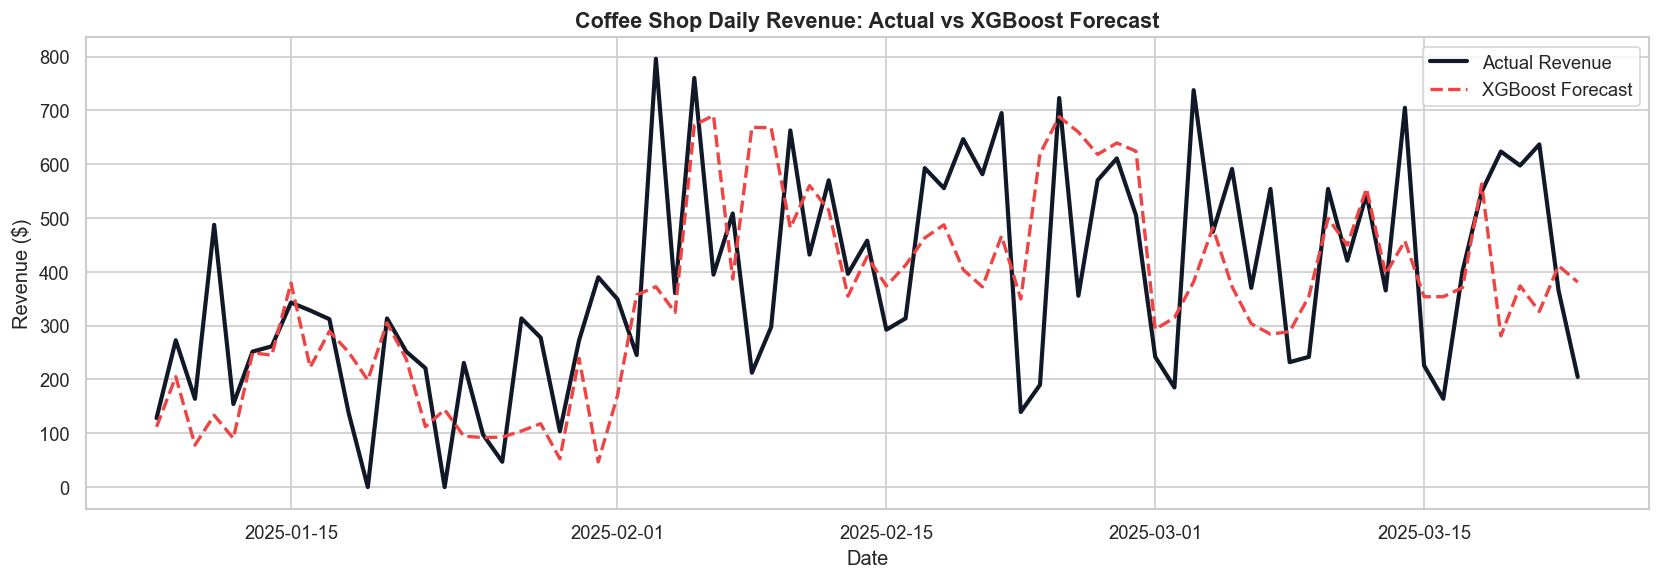

In [17]:
### 11. Final Plot of the best model: XGBoost (Actual vs Predicted)

plt.figure(figsize=(14, 5))
plt.plot(test.index, actual,    label='Actual Revenue',   color='#111827', linewidth=2.5)
plt.plot(test.index, xgb_preds, label='XGBoost Forecast', color='#ef4444', linestyle='--', linewidth=2)
plt.title('Coffee Shop Daily Revenue: Actual vs XGBoost Forecast', fontsize=13, fontweight='bold')
plt.ylabel('Revenue ($)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

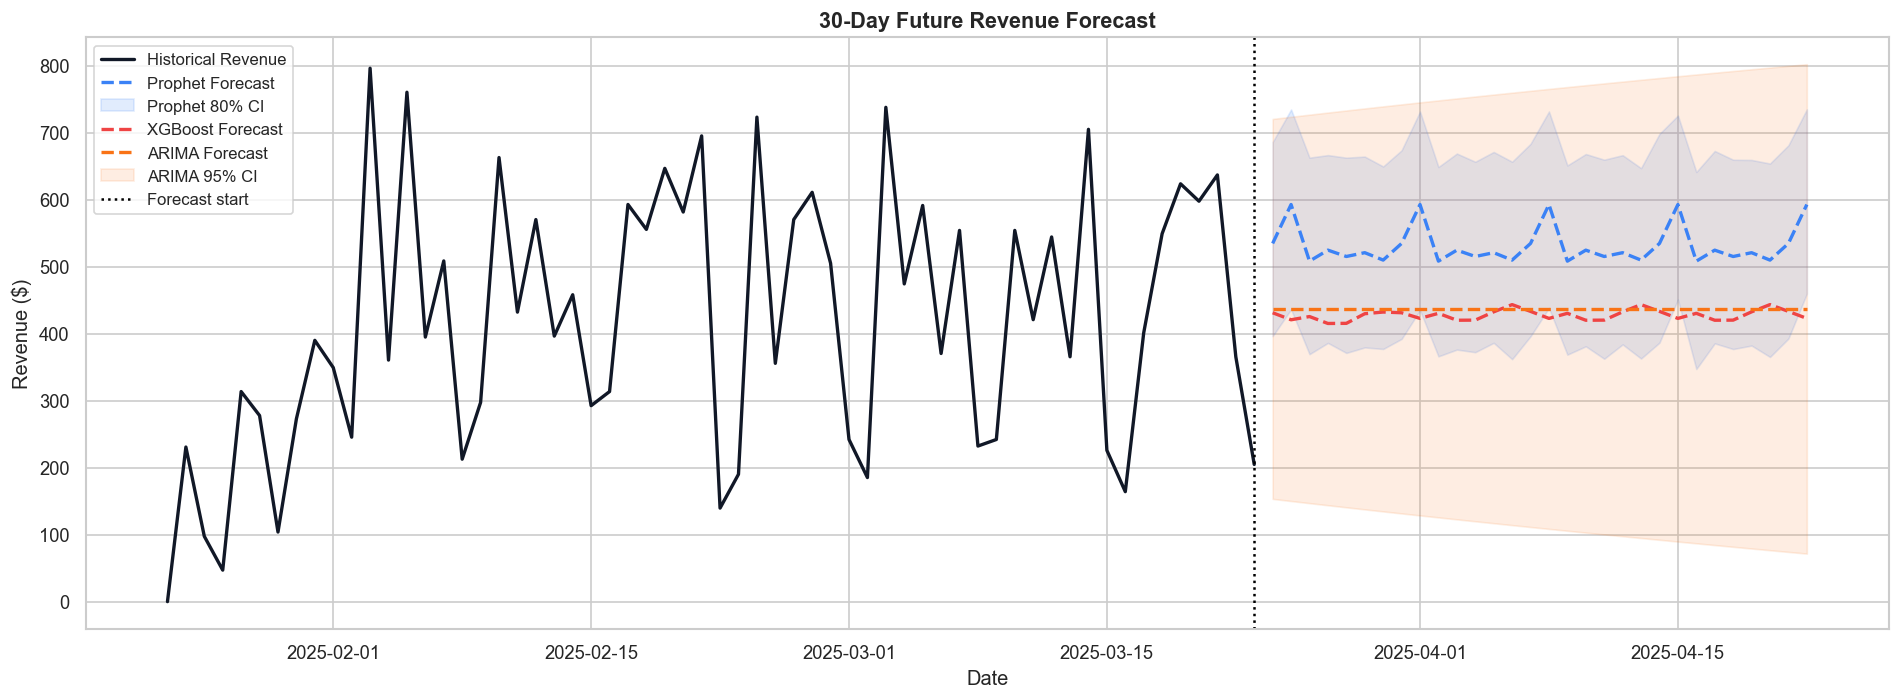


Forecast summary (30 days):
  Prophet - avg: $531.63
  XGBoost - avg: $427.63
  ARIMA - avg: $436.85


In [18]:
### 12. Future Forecast of 30 days beyond the dataset

FORECAST_HORIZON = 30  

# 12.1 Prophet future forecast (with regressors)
last_date     = daily_revenue.index.max()
future_dates  = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=FORECAST_HORIZON)

# Use of most recent rolling averages for approximation
last_lag1         = daily_revenue['revenue'].iloc[-1]
last_lag7         = daily_revenue['revenue'].iloc[-7]
last_lag14        = daily_revenue['revenue'].iloc[-14]
last_rolling_mean = daily_revenue['revenue'].iloc[-7:].mean()
last_rolling_std  = daily_revenue['revenue'].iloc[-7:].std()

future_df = pd.DataFrame({
    'ds'             : future_dates,
    'lag_1'          : last_lag1,
    'lag_7'          : last_lag7,
    'lag_14'         : last_lag14,
    'rolling_mean_7' : last_rolling_mean,
    'rolling_std_7'  : last_rolling_std,
    'is_weekend'     : np.where(future_dates.dayofweek >= 5, 1, 0),
})

future_forecast = m.predict(future_df)

# 12.2 XGBoost future forecast
future_X = pd.DataFrame({
    'dayofweek'      : future_dates.dayofweek,
    'month'          : future_dates.month,
    'is_weekend'     : np.where(future_dates.dayofweek >= 5, 1, 0),
    'lag_1'          : last_lag1,
    'lag_7'          : last_lag7,
    'lag_14'         : last_lag14,
    'rolling_mean_7' : last_rolling_mean,
    'rolling_std_7'  : last_rolling_std,
}, index=future_dates)
xgb_future_preds = xgb_model.predict(future_X)

#  12.3 ARIMA future forecast (with CI)
arima_full       = ARIMA(daily_revenue['revenue'], order=auto_model.order).fit()
arima_future_res = arima_full.get_forecast(steps=FORECAST_HORIZON)
arima_future_mean = arima_future_res.predicted_mean
arima_future_ci   = arima_future_res.conf_int(alpha=0.05)

# 12.4 Plot all three future forecasts
fig, ax = plt.subplots(figsize=(16, 6))

# Last 60 days of actuals for context
context = daily_revenue['revenue'].iloc[-60:]
ax.plot(context.index, context.values, color='#111827', linewidth=2, label='Historical Revenue')

# Prophet forecast + CI
ax.plot(future_dates, future_forecast['yhat'].values,
        color='#3b82f6', linewidth=2, linestyle='--', label='Prophet Forecast')
ax.fill_between(future_dates,
                future_forecast['yhat_lower'].values,
                future_forecast['yhat_upper'].values,
                alpha=0.15, color='#3b82f6', label='Prophet 80% CI')

# XGBoost forecast
ax.plot(future_dates, xgb_future_preds,
        color='#ef4444', linewidth=2, linestyle='--', label='XGBoost Forecast')

# ARIMA forecast + CI
ax.plot(arima_future_ci.index, arima_future_mean.values,
        color='#f97316', linewidth=2, linestyle='--', label='ARIMA Forecast')
ax.fill_between(arima_future_ci.index,
                arima_future_ci.iloc[:, 0], arima_future_ci.iloc[:, 1],
                alpha=0.12, color='#f97316', label='ARIMA 95% CI')

# Historical and forecast
ax.axvline(x=last_date, color='black', linestyle=':', linewidth=1.5, label='Forecast start')
ax.set_title(f'{FORECAST_HORIZON}-Day Future Revenue Forecast', fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue ($)')
ax.set_xlabel('Date')
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

print(f'\nForecast summary ({FORECAST_HORIZON} days):')
print(f'  Prophet - avg: ${future_forecast["yhat"].mean():.2f}')
print(f'  XGBoost - avg: ${xgb_future_preds.mean():.2f}')
print(f'  ARIMA - avg: ${arima_future_mean.mean():.2f}')

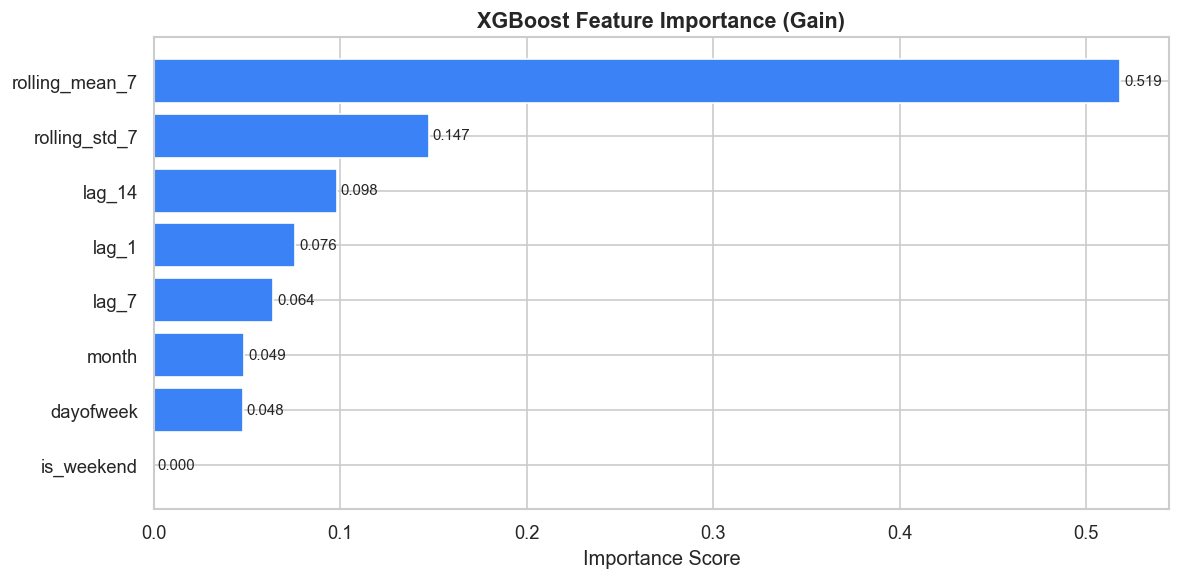

Top features:
rolling_mean_7    0.518502
rolling_std_7     0.147372
lag_14            0.098050
lag_1             0.075867
lag_7             0.064042
dtype: float32


In [19]:
### 13. XGBoost Feature Importance
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(importances.index, importances.values, color='#3b82f6', edgecolor='white')
ax.set_title('XGBoost Feature Importance (Gain)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('Top features:')
print(importances.sort_values(ascending=False).head(5))

In [20]:
### 14. Results Summary
print('FINAL MODEL COMPARISON')
print(results_df.to_string())
print()
best = results_df['MAE'].idxmin()
print(f'Winner: {best}')
print(f'MAE  = ${results_df.loc[best, "MAE"]:.2f}  (avg dollar error per day)')
print(f'RMSE = ${results_df.loc[best, "RMSE"]:.2f}')
print(f'MDA  = {results_df.loc[best, "MDA"]:.2f}%  (accuracy in prediction of change)')

FINAL MODEL COMPARISON
                      MAE    RMSE    MDA
XGBoost            135.93  179.73  62.16
Linear Regression  138.02  171.93  58.11
ARIMA              220.65  276.94   0.00
Prophet            141.88  178.00  47.30
Wtd. Ensemble      140.98  173.41  56.76

Winner: XGBoost
MAE  = $135.93  (avg dollar error per day)
RMSE = $179.73
MDA  = 62.16%  (accuracy in prediction of change)
